In [9]:
DATA_PATH = '/kaggle/input/datasets/hilalyldrm/happiness-decision/'

df = pd.read_csv(
    DATA_PATH + 'world_happiness_combined.csv',
    sep=';',
    decimal=','
)

print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nİlk 5 satır:")
df.head()

Shape: (1502, 11)

Dtypes:
Ranking                           int64
Country                          object
Regional indicator               object
Happiness score                 float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy           int64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
Year                              int64
dtype: object

İlk 5 satır:


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,7.587,8.26132,0.96240,73,0.99379,0.37289,0.23941,2015
1,2,Iceland,Western Europe,7.561,7.70416,1.00000,73,0.93884,0.54819,0.74371,2015
2,3,Denmark,Western Europe,7.527,7.84114,0.97030,70,0.96962,0.42894,0.12382,2015
3,4,Norway,Western Europe,7.522,8.63100,0.94917,71,1.00000,0.43598,0.33860,2015
4,5,Canada,North America and ANZ,7.427,7.84595,0.94322,71,0.94511,0.57560,0.40285,2015


In [12]:
print("YIL DAĞILIMI")
print(df['Year'].value_counts().sort_index())


YIL DAĞILIMI
Year
2015    158
2016    157
2017    155
2018    155
2019    155
2020    152
2021    148
2022    145
2023    137
2024    140
Name: count, dtype: int64


In [14]:
print("\nBENZERSİZ ÜLKE SAYISI (toplam)")
print(df['Country'].nunique())


BENZERSİZ ÜLKE SAYISI (toplam)
175


In [15]:

print("\nEKSİK DEĞERLER")
print(df.isnull().sum())



EKSİK DEĞERLER
Ranking                         0
Country                         0
Regional indicator              3
Happiness score                 0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
Year                            0
dtype: int64


In [16]:

print("\n ÖZET İSTATİSTİKLER")
df.describe()


 ÖZET İSTATİSTİKLER


,Ranking,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
count,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000,1502.000000
mean,76.035286,5.448857,6.107178,0.691842,66.670439,0.658935,0.320369,0.452764,2019.374834
std,43.865013,1.125638,2.499571,0.212647,7.671376,0.216441,0.172669,0.321786,2.856316
min,1.000000,1.721000,0.000000,0.000000,39.000000,0.000000,0.000000,0.000000,2015.000000
25%,38.000000,4.593425,4.375967,0.564507,62.000000,0.535942,0.196085,0.158585,2017.000000
50%,76.000000,5.469650,6.305600,0.738190,68.000000,0.690305,0.296375,0.345325,2019.000000
75%,114.000000,6.278450,8.047867,0.861528,72.000000,0.831792,0.430042,0.782560,2022.000000
max,158.000000,7.842100,10.000000,1.000000,85.000000,1.000000,1.000000,1.000000,2024.000000


      Year  Ranking  Happiness score
75    2015       76           5.3320
254   2016       78           5.3890
373   2017       69           5.5000
611   2018       74           5.4825
702   2019       79           5.3726
871   2020       93           5.1318
1066  2021      104           4.9476
1211  2022      112           4.7442


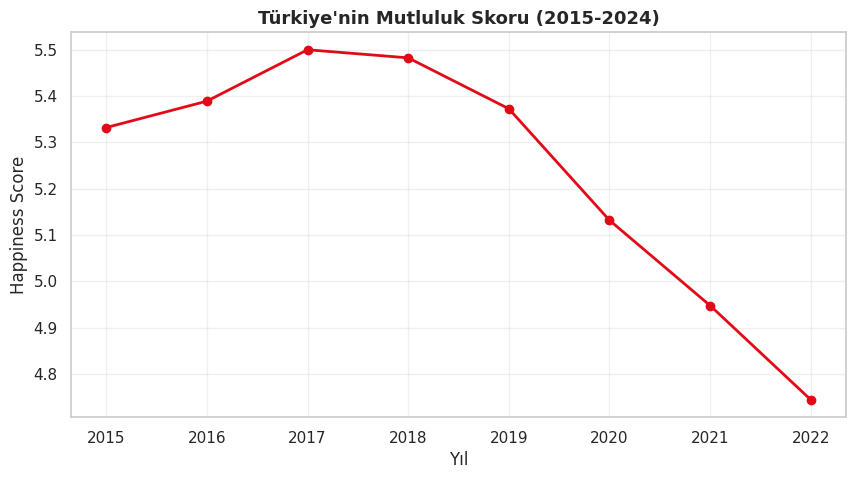

In [17]:
#Türkiye'nin 10 yıllık seyri
turkey = df[df['Country'] == 'Turkey'].sort_values('Year')
print(turkey[['Year', 'Ranking', 'Happiness score']])

plt.figure(figsize=(10, 5))
plt.plot(turkey['Year'], turkey['Happiness score'], marker='o', linewidth=2, color='#E30A17')
plt.title("Türkiye'nin Mutluluk Skoru (2015-2024)", fontsize=13, fontweight='bold')
plt.xlabel("Yıl")
plt.ylabel("Happiness Score")
plt.grid(alpha=0.3)
plt.show()

In [19]:
#Bölge dağılımı ve eksik bölgeler
print(" BÖLGE DAĞILIMI (2024)")
latest = df[df['Year'] == 2024]
print(latest['Regional indicator'].value_counts())

print("\nEksik Regional Indicator olan satırlar")
print(df[df['Regional indicator'].isnull()][['Country', 'Year']])


 BÖLGE DAĞILIMI (2024)
Regional indicator
Sub-Saharan Africa                    35
Western Europe                        23
Latin America and Caribbean           19
Middle East and North Africa          16
Central and Eastern Europe            14
Southeast Asia                         8
Commonwealth of Independent States     8
East Asia                              7
South Asia                             6
North America and ANZ                  4
Name: count, dtype: int64

Eksik Regional Indicator olan satırlar
    Country  Year
394  Greece  2017
673  Cyprus  2019
743  Gambia  2019


In [22]:
# === KDS METRIKLERI VE NORMALIZASYON ===

# Kullanacağımız 6 KPI
KDS_METRICS = [
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

# Bu metriklerden hangisi "düşük olması iyi" -> ters normalize edilecek
INVERSE_METRICS = ['Perceptions of corruption']


def normalize_metrics(data, metrics=KDS_METRICS, inverse=INVERSE_METRICS):
    """
    Verilen metrikleri min-max ile 0-1 arasına ölçeklendirir.
    Inverse listesindeki metrikler için 1 - normalize uygulanır
    (yani yüksek değer = kötü olduğu için ters çevrilir).
    """
    df_norm = data.copy()
    
    for metric in metrics:
        col_min = df_norm[metric].min()
        col_max = df_norm[metric].max()
        
        # Min-max normalizasyon
        normalized = (df_norm[metric] - col_min) / (col_max - col_min)
        
        # Düşük olması iyi olan metrikler için ters çevir
        if metric in inverse:
            normalized = 1 - normalized
        
        df_norm[f'{metric}_norm'] = normalized
    
    return df_norm


# Sadece 2024 verisiyle test edelim
df_2024 = df[df['Year'] == 2024].copy()
df_2024_norm = normalize_metrics(df_2024)

# Sonuç kontrolü
norm_cols = [f'{m}_norm' for m in KDS_METRICS]
print("=== NORMALIZASYON SONRASI (2024) ===")
print(df_2024_norm[norm_cols].describe().round(3))

print("\n=== ÖRNEK: İLK 5 ÜLKE (orijinal vs normalize) ===")
sample_cols = ['Country', 'GDP per capita', 'GDP per capita_norm', 
               'Perceptions of corruption', 'Perceptions of corruption_norm']
print(df_2024_norm[sample_cols].head().round(3))

=== NORMALIZASYON SONRASI (2024) ===
       GDP per capita_norm  Social support_norm  Healthy life expectancy_norm  \
count              140.000              140.000                       140.000   
mean                 0.644                0.702                         0.609   
std                  0.199                0.206                         0.192   
min                  0.000                0.000                         0.000   
25%                  0.503                0.570                         0.462   
50%                  0.669                0.765                         0.654   
75%                  0.813                0.856                         0.769   
max                  1.000                1.000                         1.000   

       Freedom to make life choices_norm  Generosity_norm  \
count                            140.000          140.000   
mean                               0.719            0.365   
std                                0.188          

In [23]:
# === PRESET KARAR PROFILLERI ===
# Her profil, 6 KPI'a verilen ağırlıklar (toplam = 1.0)
# Bu ağırlıklar literatür + sezgi karışımı, KDS'de "expert judgement" yaklaşımı

PROFILES = {
    'Student': {
        'GDP per capita': 0.15,
        'Social support': 0.25,
        'Healthy life expectancy': 0.10,
        'Freedom to make life choices': 0.25,
        'Generosity': 0.10,
        'Perceptions of corruption': 0.15,
    },
    'Retiree': {
        'GDP per capita': 0.15,
        'Social support': 0.20,
        'Healthy life expectancy': 0.30,
        'Freedom to make life choices': 0.05,
        'Generosity': 0.05,
        'Perceptions of corruption': 0.25,
    },
    'Family': {
        'GDP per capita': 0.20,
        'Social support': 0.25,
        'Healthy life expectancy': 0.20,
        'Freedom to make life choices': 0.15,
        'Generosity': 0.05,
        'Perceptions of corruption': 0.15,
    },
    'Entrepreneur': {
        'GDP per capita': 0.30,
        'Social support': 0.10,
        'Healthy life expectancy': 0.10,
        'Freedom to make life choices': 0.25,
        'Generosity': 0.05,
        'Perceptions of corruption': 0.20,
    },
    'Balanced': {  # Resmi WHR'a yakın - eşit ağırlık referansı
        'GDP per capita': 1/6,
        'Social support': 1/6,
        'Healthy life expectancy': 1/6,
        'Freedom to make life choices': 1/6,
        'Generosity': 1/6,
        'Perceptions of corruption': 1/6,
    }
}


def calculate_kds_score(df_normalized, weights, metrics=KDS_METRICS):
    """
    Normalize edilmiş veriye ağırlık uygular, KDS skoru üretir.
    weights: dict, metric -> weight (toplam 1.0 olmalı)
    """
    # Ağırlıkların toplamı kontrol et
    total = sum(weights.values())
    if not (0.99 <= total <= 1.01):
        print(f"⚠️  UYARI: Ağırlık toplamı {total:.3f} (1.0 olmalı)")
    
    df_result = df_normalized.copy()
    df_result['KDS_score'] = 0
    
    for metric in metrics:
        norm_col = f'{metric}_norm'
        df_result['KDS_score'] += df_result[norm_col] * weights[metric]
    
    # 0-1 -> 0-10 skalasına çevir, görsel olarak hoş
    df_result['KDS_score'] = df_result['KDS_score'] * 10
    
    # KDS sıralaması (yüksek skor = iyi)
    df_result['KDS_rank'] = df_result['KDS_score'].rank(ascending=False, method='min').astype(int)
    
    return df_result.sort_values('KDS_score', ascending=False)


# Profilleri görsel kontrol (toplamlar doğru mu)
print("=== PROFIL AĞIRLIKLARI ===")
for name, weights in PROFILES.items():
    total = sum(weights.values())
    print(f"{name:15s} | Toplam: {total:.3f}")

=== PROFIL AĞIRLIKLARI ===
Student         | Toplam: 1.000
Retiree         | Toplam: 1.000
Family          | Toplam: 1.000
Entrepreneur    | Toplam: 1.000
Balanced        | Toplam: 1.000


In [24]:
# === HER PROFIL ICIN TOP 10 ULKE ===

print("=" * 70)
print("KDS SKORLAMASI - 2024 VERISI - PROFIL BAZLI TOP 10")
print("=" * 70)

top10_results = {}

for profile_name, weights in PROFILES.items():
    scored = calculate_kds_score(df_2024_norm, weights)
    top10 = scored[['Country', 'KDS_score', 'KDS_rank', 'Ranking']].head(10).copy()
    top10.columns = ['Country', 'KDS Score', 'KDS Rank', 'Official Rank']
    top10_results[profile_name] = top10
    
    print(f"\n--- {profile_name.upper()} ---")
    print(top10.to_string(index=False))

KDS SKORLAMASI - 2024 VERISI - PROFIL BAZLI TOP 10

--- STUDENT ---
   Country  KDS Score  KDS Rank  Official Rank
   Iceland   8.702924         1              3
   Czechia   8.358977         2             18
     Malta   8.262779         3             40
  Slovenia   8.220722         4             21
  Thailand   8.183890         5             58
Kyrgyzstan   8.115081         6             74
    Kuwait   8.114747         7             13
 Indonesia   7.934449         8             79
  Portugal   7.848905         9             55
 Australia   7.775211        10             10

--- RETIREE ---
 Country  KDS Score  KDS Rank  Official Rank
 Iceland   8.359517         1              3
   Malta   8.295637         2             40
 Czechia   8.192535         3             18
Portugal   8.168674         4             55
  Cyprus   8.164338         5             50
Slovenia   8.118962         6             21
Thailand   8.083673         7             58
   Italy   8.060449         8         

In [25]:
# === TUM PROFILLERIN TOP 10'LARI YAN YANA ===

comparison = pd.DataFrame({
    profile: top10_results[profile]['Country'].values
    for profile in PROFILES.keys()
})
comparison.index = [f'#{i+1}' for i in range(10)]

print("=== PROFIL BAZLI TOP 10 ÜLKE (YAN YANA) ===\n")
print(comparison.to_string())

# Türkiye her profilde kaçıncı?
print("\n=== TÜRKİYE'NİN PROFIL BAZLI SIRALAMASI (2024) ===")
turkey_2024 = df_2024_norm[df_2024_norm['Country'] == 'Turkey']

if len(turkey_2024) > 0:
    print(f"Resmi WHR Sıralaması: {turkey_2024['Ranking'].values[0]}")
    print()
    for profile_name, weights in PROFILES.items():
        scored = calculate_kds_score(df_2024_norm, weights)
        tr_row = scored[scored['Country'] == 'Turkey']
        if len(tr_row) > 0:
            rank = tr_row['KDS_rank'].values[0]
            score = tr_row['KDS_score'].values[0]
            print(f"  {profile_name:15s} | Sıra: {rank:3d}/140 | Skor: {score:.3f}")
else:
    print("Türkiye 2024 verisinde yok!")

=== PROFIL BAZLI TOP 10 ÜLKE (YAN YANA) ===

        Student   Retiree    Family Entrepreneur                Balanced
#1      Iceland   Iceland   Iceland      Iceland                 Iceland
#2      Czechia     Malta     Malta      Czechia                   Malta
#3        Malta   Czechia   Czechia        Malta                Thailand
#4     Slovenia  Portugal  Slovenia     Slovenia                 Czechia
#5     Thailand    Cyprus  Portugal       Kuwait               Indonesia
#6   Kyrgyzstan  Slovenia    Kuwait     Portugal                Slovenia
#7       Kuwait  Thailand    Israel     Thailand                  Kuwait
#8    Indonesia     Italy  Thailand       Panama              Kyrgyzstan
#9     Portugal    Israel    Panama      Romania  Bosnia and Herzegovina
#10   Australia  Slovakia  Slovakia     Malaysia                  Kosovo

=== TÜRKİYE'NİN PROFIL BAZLI SIRALAMASI (2024) ===
Türkiye 2024 verisinde yok!


In [26]:
# === 2024 DATASET DOĞRULAMASI ===
# Resmi Ranking kolonunun top 10'u gerçekten WHR top 10 mu?

print("=== 2024 RESMI WHR TOP 10 (dataset'in Ranking kolonuna göre) ===")
official_top10 = df_2024.sort_values('Ranking').head(10)
print(official_top10[['Ranking', 'Country', 'Happiness score', 'GDP per capita',
                       'Social support', 'Healthy life expectancy']].to_string(index=False))

print("\n=== 2024 DATASET'TEKI EN YÜKSEK HAPPINESS SCORE TOP 10 ===")
score_top10 = df_2024.sort_values('Happiness score', ascending=False).head(10)
print(score_top10[['Ranking', 'Country', 'Happiness score']].to_string(index=False))

print("\n=== TÜRKIYE 2024'te var mı? ===")
print(df_2024[df_2024['Country'].str.contains('urk', case=False, na=False)])

=== 2024 RESMI WHR TOP 10 (dataset'in Ranking kolonuna göre) ===
 Ranking     Country  Happiness score  GDP per capita  Social support  Healthy life expectancy
       1     Finland           7.7407         8.61498         0.97268                       76
       2     Denmark           7.5827         8.91278         0.94051                       76
       3     Iceland           7.5251         8.78627         1.00000                       77
       4      Sweden           7.3441         8.77425         0.92843                       77
       5      Israel           7.3411         8.42288         0.93583                       78
       6 Netherlands           7.3194         8.87942         0.90444                       76
       7      Norway           7.3017         9.11908         0.93815                       76
       8  Luxembourg           7.1219        10.00000         0.83799                       77
       9 Switzerland           7.0602         9.20463         0.88148           

In [27]:
# === DÜZELTMELER ===

# 1) Ülke isim standardizasyonu (Turkey -> Turkiye birleştir)
df['Country'] = df['Country'].replace({'Turkey': 'Turkiye'})
df_2024 = df[df['Year'] == 2024].copy()
df_2024_norm = normalize_metrics(df_2024)

# 2) Türkiye 2024 KDS sıralaması (artık çalışmalı)
print("=== TÜRKİYE 2024 - KDS PROFILLERE GÖRE SIRALAMA ===\n")
print(f"Resmi WHR 2024 sırası: 96/140")
print(f"Resmi Happiness Score: 4.9753")
print()

for profile_name, weights in PROFILES.items():
    scored = calculate_kds_score(df_2024_norm, weights)
    tr_row = scored[scored['Country'] == 'Turkiye']
    if len(tr_row) > 0:
        rank = tr_row['KDS_rank'].values[0]
        score = tr_row['KDS_score'].values[0]
        print(f"  {profile_name:15s} | Sıra: {rank:3d}/140 | KDS Skoru: {score:.2f}")

# 3) KDS skoru ile resmi WHR sıralaması arasındaki korelasyon - sağlık kontrolü
print("\n=== KDS vs RESMI WHR SIRALAMA KORELASYONU ===")
print("(KDS makul mü? Resmi sıralamayla aynı yöne mi gidiyor?)\n")

for profile_name, weights in PROFILES.items():
    scored = calculate_kds_score(df_2024_norm, weights)
    # KDS_rank ile Ranking (resmi) arasındaki Spearman korelasyonu
    corr = scored[['KDS_rank', 'Ranking']].corr(method='spearman').iloc[0, 1]
    print(f"  {profile_name:15s} | Spearman korelasyonu: {corr:+.3f}")

=== TÜRKİYE 2024 - KDS PROFILLERE GÖRE SIRALAMA ===

Resmi WHR 2024 sırası: 96/140
Resmi Happiness Score: 4.9753

  Student         | Sıra: 107/140 | KDS Skoru: 5.70
  Retiree         | Sıra:  58/140 | KDS Skoru: 7.04
  Family          | Sıra:  89/140 | KDS Skoru: 6.51
  Entrepreneur    | Sıra: 102/140 | KDS Skoru: 6.11
  Balanced        | Sıra:  99/140 | KDS Skoru: 5.76

=== KDS vs RESMI WHR SIRALAMA KORELASYONU ===
(KDS makul mü? Resmi sıralamayla aynı yöne mi gidiyor?)

  Student         | Spearman korelasyonu: +0.818
  Retiree         | Spearman korelasyonu: +0.676
  Family          | Spearman korelasyonu: +0.839
  Entrepreneur    | Spearman korelasyonu: +0.784
  Balanced        | Spearman korelasyonu: +0.795


=== TÜRKİYE 2015-2024: PROFIL BAZLI SIRALAMA SEYRİ ===

 Year  Official Rank  Happiness  Student  Retiree  Family  Entrepreneur  Balanced
 2015             76       5.33       98       62      84            89        90
 2016             78       5.39      105       77      89           110       106
 2017             69       5.50       90       64      74            86        91
 2018             74       5.48       83       61      66            81        80
 2019             79       5.37      102       75      82            96        98
 2020             93       5.13       97       63      81            92        96
 2021            104       4.95      101       71      89            99       100
 2022            112       4.74      108       72      90            97        96
 2023            106       4.61      107       70      94           101       101
 2024             96       4.98      107       58      89           102        99


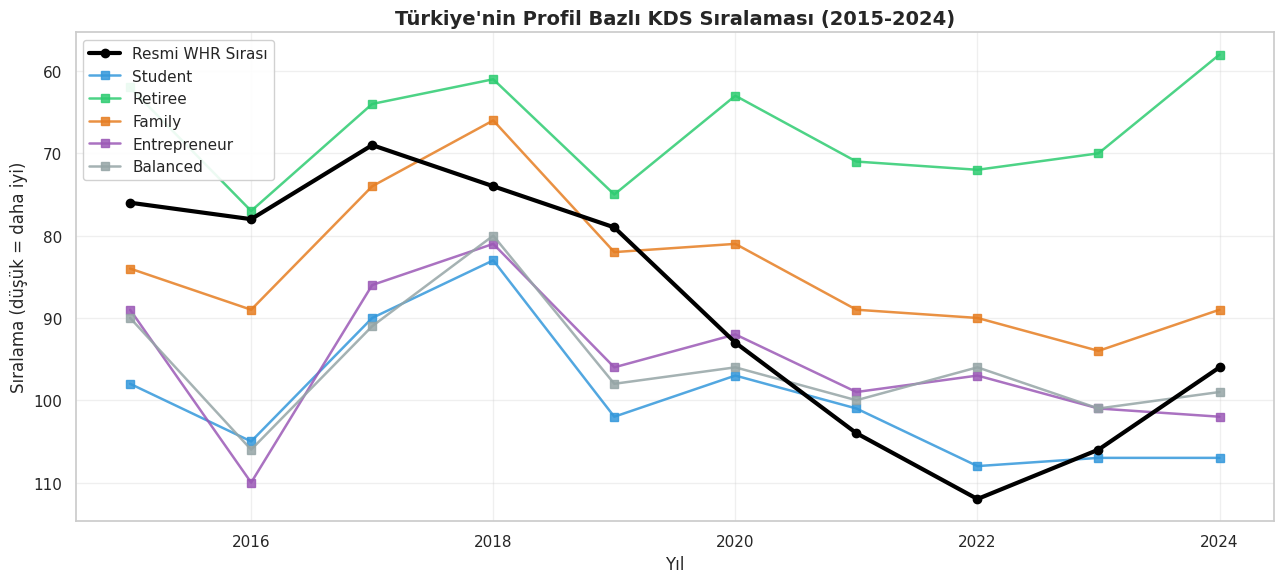

In [28]:
# === TURKIYE'NIN YILLAR ARASI PROFIL BAZLI SIRALAMASI ===

# Tüm yıllar için normalize edip her profilin Türkiye sıralamasını hesapla
turkey_journey = []

for year in sorted(df['Year'].unique()):
    df_year = df[df['Year'] == year].copy()
    df_year_norm = normalize_metrics(df_year)
    
    tr_check = df_year_norm[df_year_norm['Country'] == 'Turkiye']
    if len(tr_check) == 0:
        continue
    
    row = {'Year': year, 'Official Rank': int(tr_check['Ranking'].values[0]),
           'Happiness': round(tr_check['Happiness score'].values[0], 2)}
    
    for profile_name, weights in PROFILES.items():
        scored = calculate_kds_score(df_year_norm, weights)
        tr_row = scored[scored['Country'] == 'Turkiye']
        row[profile_name] = int(tr_row['KDS_rank'].values[0])
    
    turkey_journey.append(row)

turkey_df = pd.DataFrame(turkey_journey)
print("=== TÜRKİYE 2015-2024: PROFIL BAZLI SIRALAMA SEYRİ ===\n")
print(turkey_df.to_string(index=False))


# === GORSELLESTIRME ===
plt.figure(figsize=(13, 6))

# Resmi sıralama kalın siyah
plt.plot(turkey_df['Year'], turkey_df['Official Rank'], 
         marker='o', linewidth=3, color='black', label='Resmi WHR Sırası', zorder=10)

# Profiller
colors = {'Student': '#3498db', 'Retiree': '#2ecc71', 'Family': '#e67e22', 
          'Entrepreneur': '#9b59b6', 'Balanced': '#95a5a6'}

for profile, color in colors.items():
    plt.plot(turkey_df['Year'], turkey_df[profile], 
             marker='s', linewidth=1.8, alpha=0.85, label=profile, color=color)

plt.gca().invert_yaxis()  # Sıralama düşük = iyi, ters çevir
plt.title("Türkiye'nin Profil Bazlı KDS Sıralaması (2015-2024)", 
          fontsize=14, fontweight='bold')
plt.xlabel("Yıl")
plt.ylabel("Sıralama (düşük = daha iyi)")
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
################################################################################################

In [30]:
# === HER ÜLKENIN 10 YILLIK ORTALAMA PROFILI ===

# Tüm yılları normalize et, sonra ülke bazında ortala
df_all_norm = normalize_metrics(df)
norm_cols = [f'{m}_norm' for m in KDS_METRICS]

# Ülke bazında ortalama (10 yıllık profil)
country_profiles = df_all_norm.groupby('Country')[norm_cols].mean()

# Sadece yeterli yıl verisi olan ülkeleri al (en az 5 yıl)
country_year_counts = df.groupby('Country')['Year'].count()
valid_countries = country_year_counts[country_year_counts >= 5].index
country_profiles = country_profiles.loc[valid_countries]

print(f"Toplam ülke: {len(country_profiles)}")
print(f"\nHer ülkenin ortalama profili (ilk 5):")
print(country_profiles.head().round(3))

# Türkiye'nin profili (referans için)
print(f"\nTürkiye'nin 10 yıllık ortalama profili:")
print(country_profiles.loc['Turkiye'].round(3))

Toplam ülke: 153

Her ülkenin ortalama profili (ilk 5):
             GDP per capita_norm  Social support_norm  \
Country                                                 
Afghanistan                0.311                0.142   
Albania                    0.630                0.521   
Argelia                    0.597                0.710   
Argentina                  0.705                0.849   
Armenia                    0.600                0.620   

             Healthy life expectancy_norm  Freedom to make life choices_norm  \
Country                                                                        
Afghanistan                         0.378                              0.090   
Albania                             0.702                              0.638   
Argelia                             0.652                              0.212   
Argentina                           0.680                              0.746   
Armenia                             0.659                       

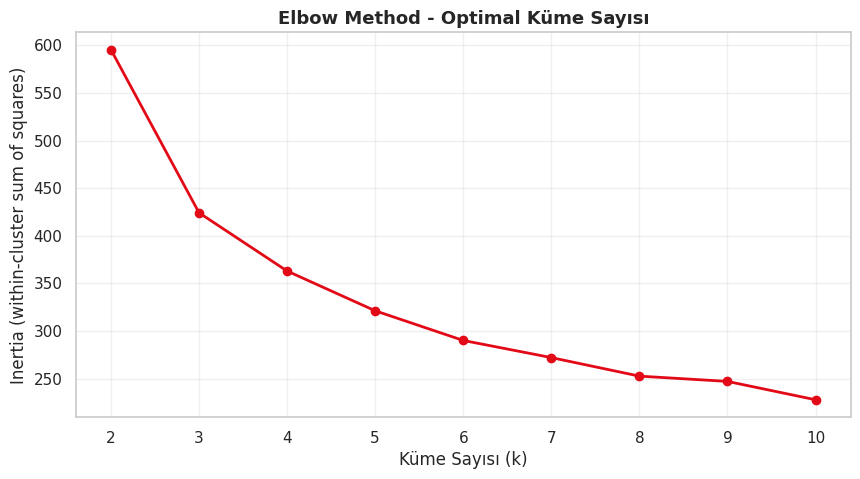

Inertia değerleri:
  k=2: 595.36
  k=3: 424.14
  k=4: 363.00
  k=5: 321.27
  k=6: 290.10
  k=7: 272.12
  k=8: 252.65
  k=9: 247.11
  k=10: 227.84


In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# K-means input için array
X = country_profiles.values

# Veri zaten 0-1 normalize ama K-means için ekstra StandardScaler iyi olur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2, color='#E30A17')
plt.title("Elbow Method - Optimal Küme Sayısı", fontsize=13, fontweight='bold')
plt.xlabel("Küme Sayısı (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.grid(alpha=0.3)
plt.xticks(k_range)
plt.show()

print("Inertia değerleri:")
for k, i in zip(k_range, inertias):
    print(f"  k={k}: {i:.2f}")

=== PCA Açıklanan Varyans ===
  PC1: 53.5%
  PC2: 21.6%
  Toplam: 75.2%

=== PCA Loadings (Component Anlamlandırma) ===
                                PC1    PC2
GDP per capita                0.508 -0.227
Social support                0.491 -0.174
Healthy life expectancy       0.495 -0.209
Freedom to make life choices  0.394  0.334
Generosity                    0.035  0.742
Perceptions of corruption    -0.316 -0.461


/tmp/ipykernel_57/2681913327.py:67: UserWarning: Glyph 127481 (\N{REGIONAL INDICATOR SYMBOL LETTER T}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/2681913327.py:67: UserWarning: Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127481 (\N{REGIONAL INDICATOR SYMBOL LETTER T}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


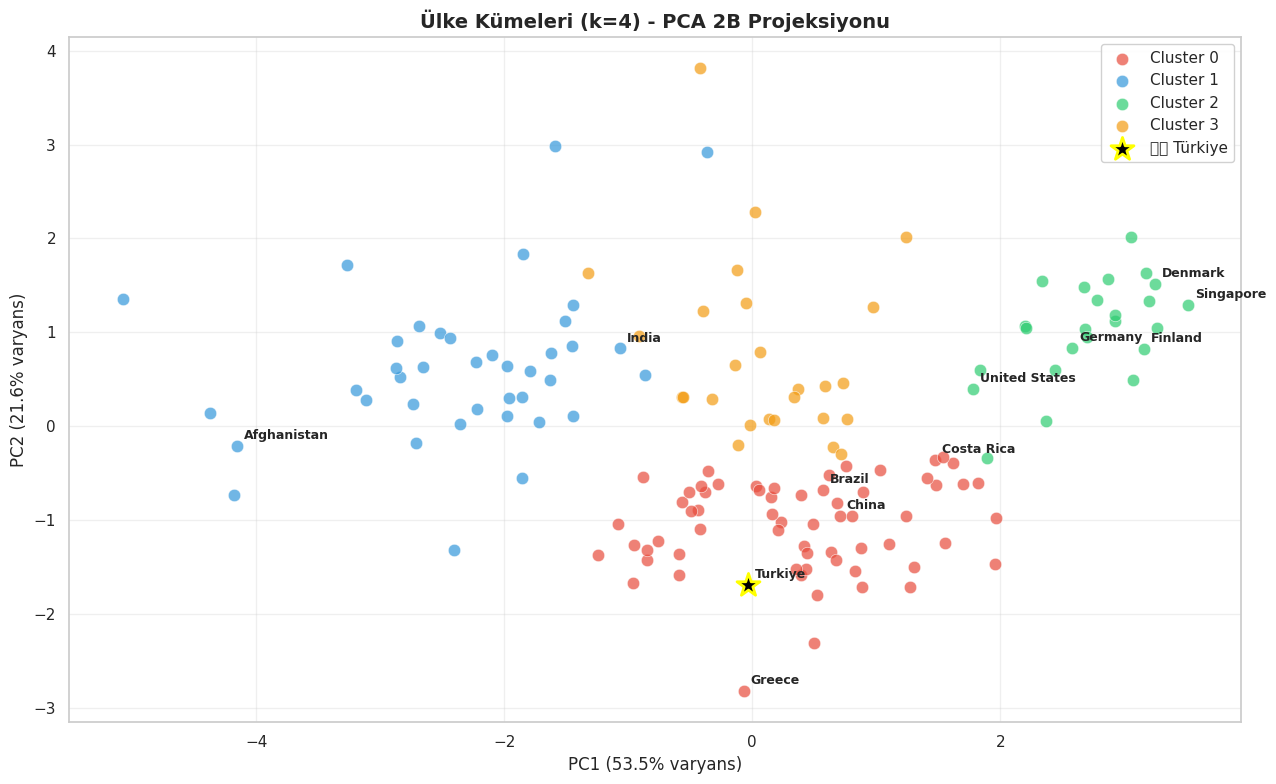

In [32]:
from sklearn.decomposition import PCA

# === K=4 ILE FINAL CLUSTERING ===
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Sonuçları DataFrame'e ekle
country_profiles_clustered = country_profiles.copy()
country_profiles_clustered['Cluster'] = cluster_labels

# === PCA - 6 boyutu 2'ye dusur ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"=== PCA Açıklanan Varyans ===")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Toplam: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# PCA loadings (her PC hangi metrikten ne kadar etkileniyor)
print(f"\n=== PCA Loadings (Component Anlamlandırma) ===")
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=[m.replace('_norm','') for m in norm_cols]
)
print(loadings.round(3))


# === GORSEL ===
plt.figure(figsize=(13, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = [f'Cluster {i}' for i in range(OPTIMAL_K)]  # geçici, sonra isim vereceğiz

for cluster_id in range(OPTIMAL_K):
    mask = cluster_labels == cluster_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[cluster_id], s=80, alpha=0.7,
                label=cluster_names[cluster_id], edgecolor='white', linewidth=0.5)

# Turkiye'yi vurgula
tr_idx = list(country_profiles.index).index('Turkiye')
plt.scatter(X_pca[tr_idx, 0], X_pca[tr_idx, 1], 
            c='black', s=300, marker='*', zorder=10, 
            edgecolor='yellow', linewidth=2, label='🇹🇷 Türkiye')

# Bazı önemli ülkeleri etiketle
highlight_countries = ['Turkiye', 'Finland', 'Denmark', 'Afghanistan', 
                       'United States', 'Brazil', 'India', 'China', 
                       'Germany', 'Singapore', 'Costa Rica', 'Greece']
for country in highlight_countries:
    if country in country_profiles.index:
        idx = list(country_profiles.index).index(country)
        plt.annotate(country, (X_pca[idx, 0], X_pca[idx, 1]),
                    fontsize=9, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')

plt.title(f"Ülke Kümeleri (k={OPTIMAL_K}) - PCA 2B Projeksiyonu", 
          fontsize=14, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varyans)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varyans)")
plt.legend(loc='best', framealpha=0.9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# === KUMELERIN KARAKTERIZASYONU ===

country_profiles_clustered['Country'] = country_profiles_clustered.index

# Her kümenin metrik ortalamaları
cluster_means = country_profiles_clustered.groupby('Cluster')[norm_cols].mean()
cluster_means.columns = [c.replace('_norm', '') for c in cluster_means.columns]
cluster_sizes = country_profiles_clustered.groupby('Cluster').size()

print("=== KÜME PROFILLERI (normalized 0-1) ===\n")
print(cluster_means.round(3))
print(f"\n=== KÜME BÜYÜKLÜKLERI ===")
print(cluster_sizes)

# Her kümeden örnek ülkeler
print("\n=== HER KÜMEDEN ÖRNEK ÜLKELER ===\n")
for cluster_id in range(OPTIMAL_K):
    members = country_profiles_clustered[country_profiles_clustered['Cluster'] == cluster_id].index.tolist()
    print(f"--- Cluster {cluster_id} ({len(members)} ülke) ---")
    # İlk 12 ülke
    print(", ".join(sorted(members)[:12]))
    print()

# Türkiye'nin kümesi ve aynı kümedekiler
tr_cluster = country_profiles_clustered.loc['Turkiye', 'Cluster']
print(f"\n=== TÜRKİYE'NIN KÜMESI: Cluster {tr_cluster} ===")
tr_cluster_members = country_profiles_clustered[
    country_profiles_clustered['Cluster'] == tr_cluster
].index.tolist()
print(f"Türkiye ile aynı kümede {len(tr_cluster_members)} ülke var:")
print(", ".join(sorted(tr_cluster_members)))

=== KÜME PROFILLERI (normalized 0-1) ===

         GDP per capita  Social support  Healthy life expectancy  \
Cluster                                                            
0                 0.692           0.754                    0.663   
1                 0.332           0.428                    0.412   
2                 0.870           0.890                    0.755   
3                 0.562           0.719                    0.587   

         Freedom to make life choices  Generosity  Perceptions of corruption  
Cluster                                                                       
0                               0.611       0.196                      0.564  
1                               0.510       0.359                      0.558  
2                               0.879       0.450                      0.467  
3                               0.776       0.471                      0.562  

=== KÜME BÜYÜKLÜKLERI ===
Cluster
0    64
1    39
2    24
3    26
dtype: i

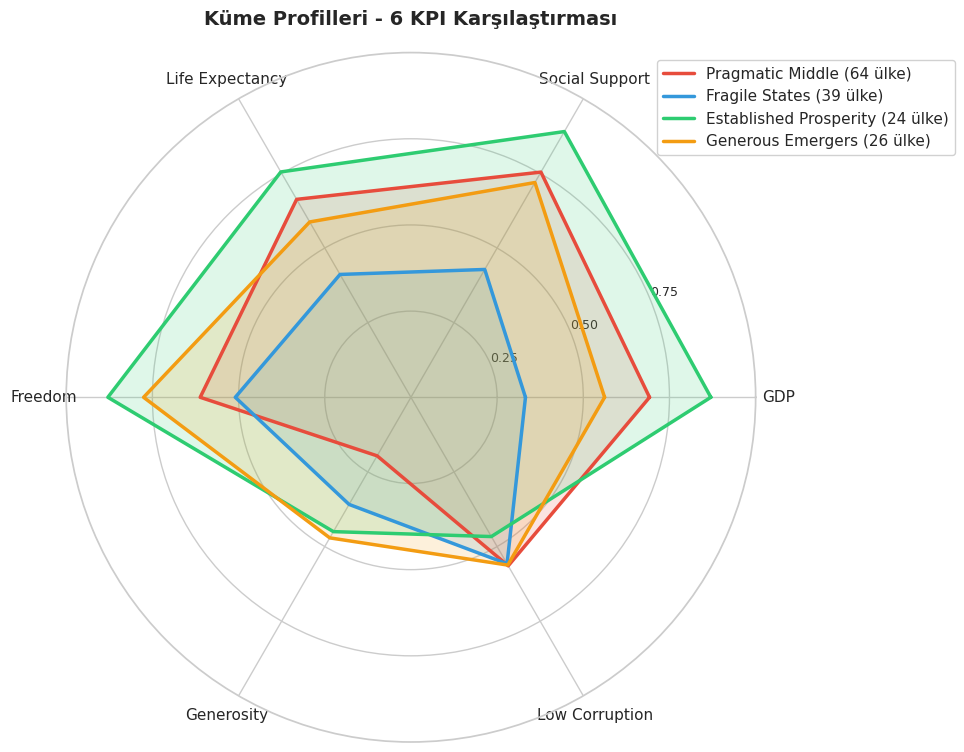

=== TÜRKİYE'YE EN BENZEYEN 15 ÜLKE (Euclidean profil mesafesi) ===

  Montenegro                     | Mesafe: 0.178 | Küme: Pragmatic Middle
  Belarus                        | Mesafe: 0.183 | Küme: Pragmatic Middle
  Argelia                        | Mesafe: 0.196 | Küme: Pragmatic Middle
  Greece                         | Mesafe: 0.199 | Küme: Pragmatic Middle
  Croatia                        | Mesafe: 0.206 | Küme: Pragmatic Middle
  Hungary                        | Mesafe: 0.214 | Küme: Pragmatic Middle
  Lebanon                        | Mesafe: 0.221 | Küme: Pragmatic Middle
  South Korea                    | Mesafe: 0.233 | Küme: Pragmatic Middle
  Italy                          | Mesafe: 0.237 | Küme: Pragmatic Middle
  Iraq                           | Mesafe: 0.257 | Küme: Pragmatic Middle
  Lithuania                      | Mesafe: 0.259 | Küme: Pragmatic Middle
  Armenia                        | Mesafe: 0.264 | Küme: Pragmatic Middle
  Latvia                         | Mesafe: 0

In [35]:
# === KUMELERE ISIM VER + FINAL VIZUAL ===

CLUSTER_NAMES = {
    0: 'Pragmatic Middle',      # Türkiye'nin kümesi
    1: 'Fragile States',
    2: 'Established Prosperity',
    3: 'Generous Emergers'
}

CLUSTER_NAMES_TR = {
    0: 'Pragmatik Orta',
    1: 'Kırılgan Devletler',
    2: 'Refah Zirvesi',
    3: 'Cömert Yükselenler'
}

# DataFrame'e isim olarak ekle
country_profiles_clustered['Cluster_Name'] = country_profiles_clustered['Cluster'].map(CLUSTER_NAMES)

# === RADAR CHART: Her küme nasıl bir profil çiziyor ===
from math import pi

categories = [c.replace('Perceptions of corruption', 'Low Corruption')
               .replace('Healthy life expectancy', 'Life Expectancy')
               .replace('Freedom to make life choices', 'Freedom')
               .replace('GDP per capita', 'GDP')
               .replace('Social support', 'Social Support')
              for c in cluster_means.columns]

N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # close loop

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

colors = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71', 3: '#f39c12'}

for cluster_id in range(OPTIMAL_K):
    values = cluster_means.iloc[cluster_id].tolist()
    values += values[:1]  # close loop
    ax.plot(angles, values, linewidth=2.5, label=f"{CLUSTER_NAMES[cluster_id]} ({cluster_sizes[cluster_id]} ülke)",
            color=colors[cluster_id])
    ax.fill(angles, values, alpha=0.15, color=colors[cluster_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=9)
plt.title('Küme Profilleri - 6 KPI Karşılaştırması', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), framealpha=0.9)
plt.tight_layout()
plt.show()


# === TÜRKİYE'NIN KÜMESINDEKI KOMSULAR (En benzer 10) ===
from scipy.spatial.distance import cdist

tr_profile = country_profiles.loc['Turkiye'].values.reshape(1, -1)
distances = cdist(tr_profile, country_profiles.values)[0]

distance_df = pd.DataFrame({
    'Country': country_profiles.index,
    'Distance': distances,
    'Cluster': cluster_labels
})
distance_df = distance_df[distance_df['Country'] != 'Turkiye'].sort_values('Distance')

print("=== TÜRKİYE'YE EN BENZEYEN 15 ÜLKE (Euclidean profil mesafesi) ===\n")
for _, row in distance_df.head(15).iterrows():
    cn = CLUSTER_NAMES[row['Cluster']]
    print(f"  {row['Country']:30s} | Mesafe: {row['Distance']:.3f} | Küme: {cn}")